### Fiap - Aula de estatistica e modelos - IA e Data Science



Dado um conjunto de dados com informações de vinhos tintos portugueses, seu objetivo é criar um modelo de Regressão Linear Multipla capaz de prever a qualidade do vinho.

1 - Analise os dados para descobrir quais são as variaveis mais importantes para discriminar a variavel Target;

2 - Trate os dados caso seja necessario;

3 - Construa um modelo de regressão e avalie a performance.

In [215]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


tabela_vinhos = pd.read_csv('winequality-red.csv')
tabela_vinhos.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [216]:
#Informação do data frame
tabela_vinhos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [228]:
#Valores faltantes
tabela_vinhos.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [229]:
#Analise dos dados
tabela_vinhos.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


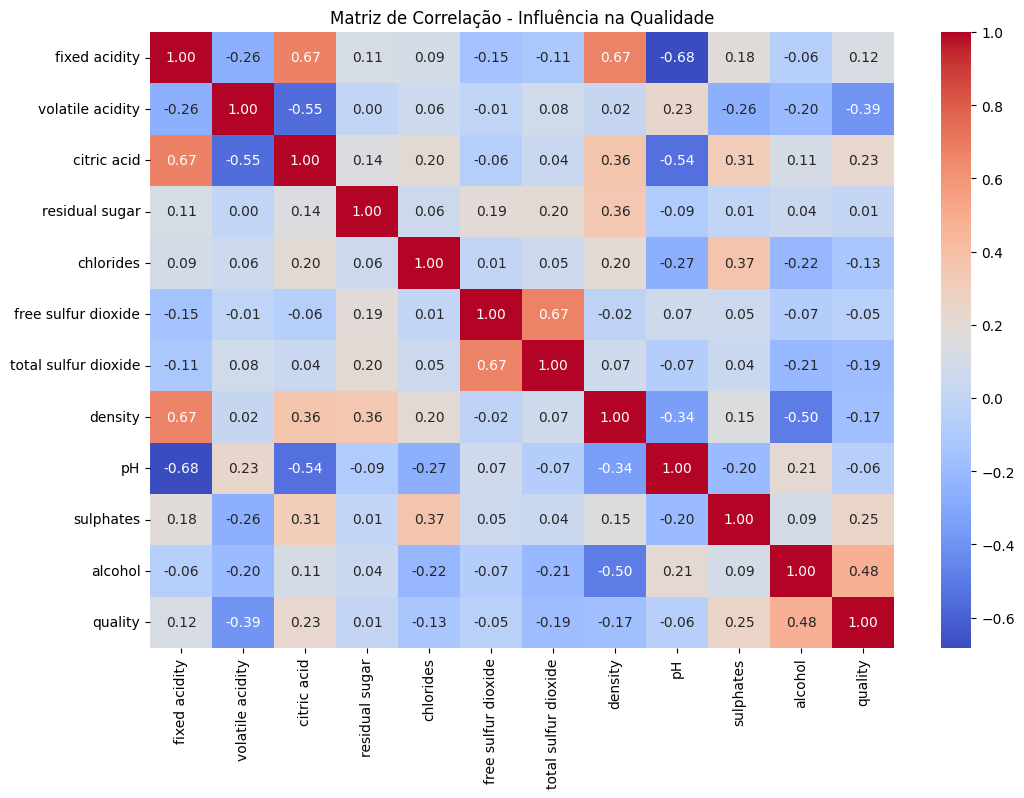

In [230]:
#Correlação de dados

corr_matrix = tabela_vinhos.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Matriz de Correlação - Influência na Qualidade')
plt.show()

array([[<Axes: xlabel='quality', ylabel='quality'>,
        <Axes: xlabel='sulphates', ylabel='quality'>,
        <Axes: xlabel='citric acid', ylabel='quality'>,
        <Axes: xlabel='alcohol', ylabel='quality'>],
       [<Axes: xlabel='quality', ylabel='sulphates'>,
        <Axes: xlabel='sulphates', ylabel='sulphates'>,
        <Axes: xlabel='citric acid', ylabel='sulphates'>,
        <Axes: xlabel='alcohol', ylabel='sulphates'>],
       [<Axes: xlabel='quality', ylabel='citric acid'>,
        <Axes: xlabel='sulphates', ylabel='citric acid'>,
        <Axes: xlabel='citric acid', ylabel='citric acid'>,
        <Axes: xlabel='alcohol', ylabel='citric acid'>],
       [<Axes: xlabel='quality', ylabel='alcohol'>,
        <Axes: xlabel='sulphates', ylabel='alcohol'>,
        <Axes: xlabel='citric acid', ylabel='alcohol'>,
        <Axes: xlabel='alcohol', ylabel='alcohol'>]], dtype=object)

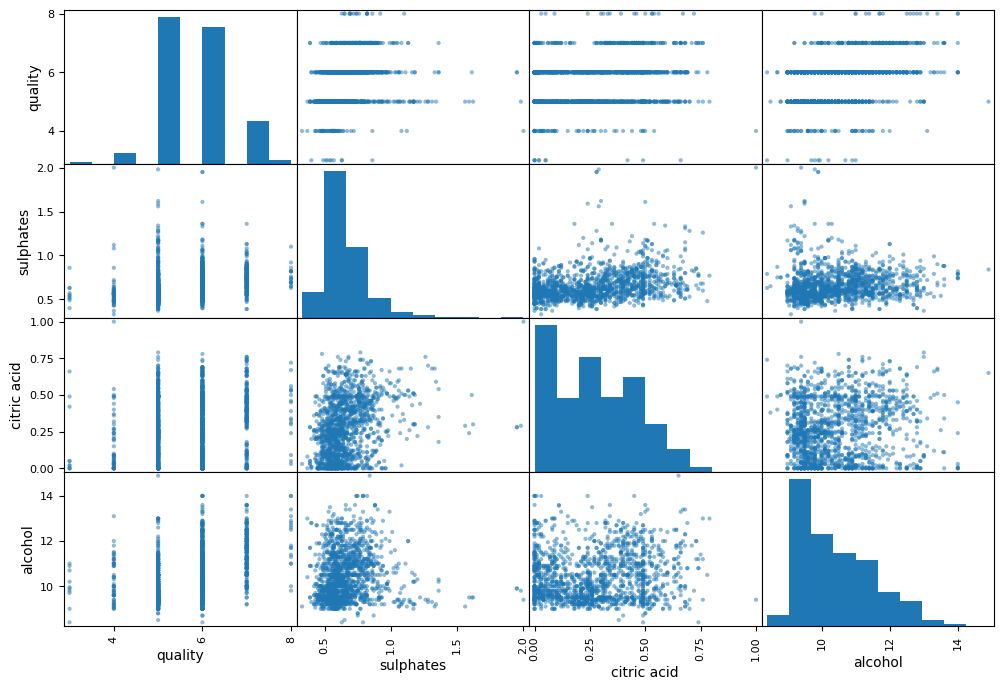

In [231]:
#Matriz de Dispersão, para tentar avaliar correlação entre as principais variaveis

attributes = ["quality", "sulphates", "citric acid", "alcohol"]

scatter_matrix(tabela_vinhos[attributes], figsize=(12, 8))

###Analise de Correlação

Pela matriz de correlação, os dados mais proximos são o de alcool, sulfatos e acido citrico, porem com valores bem distantes de 1.

Não é possivel verificar correlação forte entre uma variavel unica e a qualidade.

Importante notar que pela qualidade ser um numero sempre inteiro, acaba se gerando essas linhas verticais nos graficos de dispersão, se isso for um incomodo podemos transformar os dados de qualidade em um dado categorico, como bom ou ruim.

Proximo passo: Veirifcar se temos outliers e se devemos retira-los.

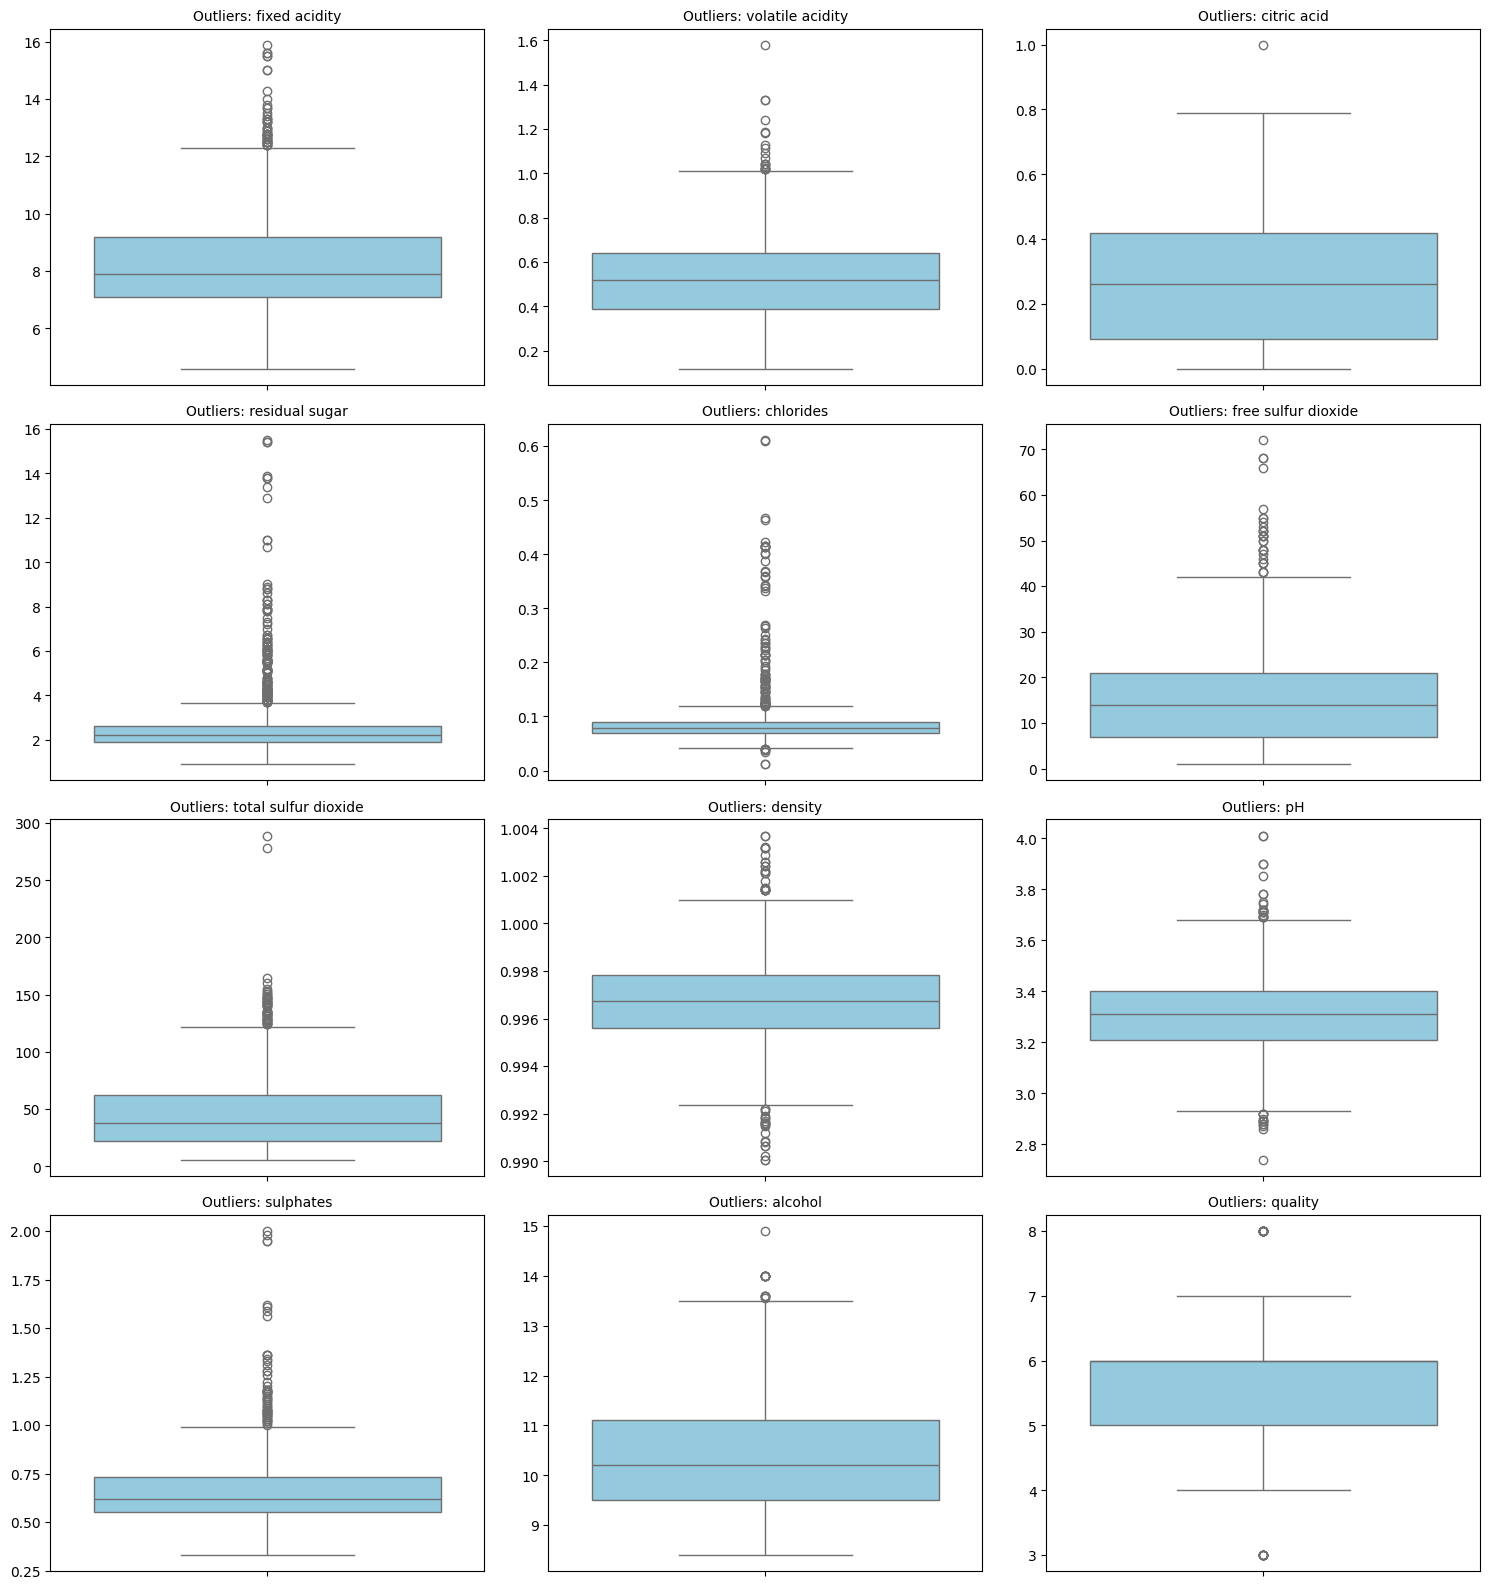

In [232]:
#Verificando outliers

# Seleciona apenas as colunas numéricas (para não dar erro)
colunas_numericas = tabela_vinhos.select_dtypes(include=['number']).columns
n_cols = 3
n_rows = (len(colunas_numericas) + n_cols - 1) // n_cols

# Cria a figura com o tamanho ajustado
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() # Transforma a matriz de eixos em lista simples

for i, col in enumerate(colunas_numericas):
    sns.boxplot(y=tabela_vinhos[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Outliers: {col}', fontsize=10)
    axes[i].set_ylabel('')

# Remove eixos vazios que sobrarem
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

###Analise de Outliers

Analisando os Boxplotes acima, é possivel verificar que existem muitos valores que podem ser possiveis outliers, porem nenhum numero parece estar fugindo da realidade da sua natureza, se limitando a intervalos possivelmente reais.

Proximo passo: Verificar a distribuição dos dados, com isso é possivel verificar se há distribuição normal dos dados e se podemos usar modelos mais simples como regressão linear ou se devemos ir para modelos mais complexos. Podemos tambem verificar se podemos ter problemas com os extremos por falta de dados.

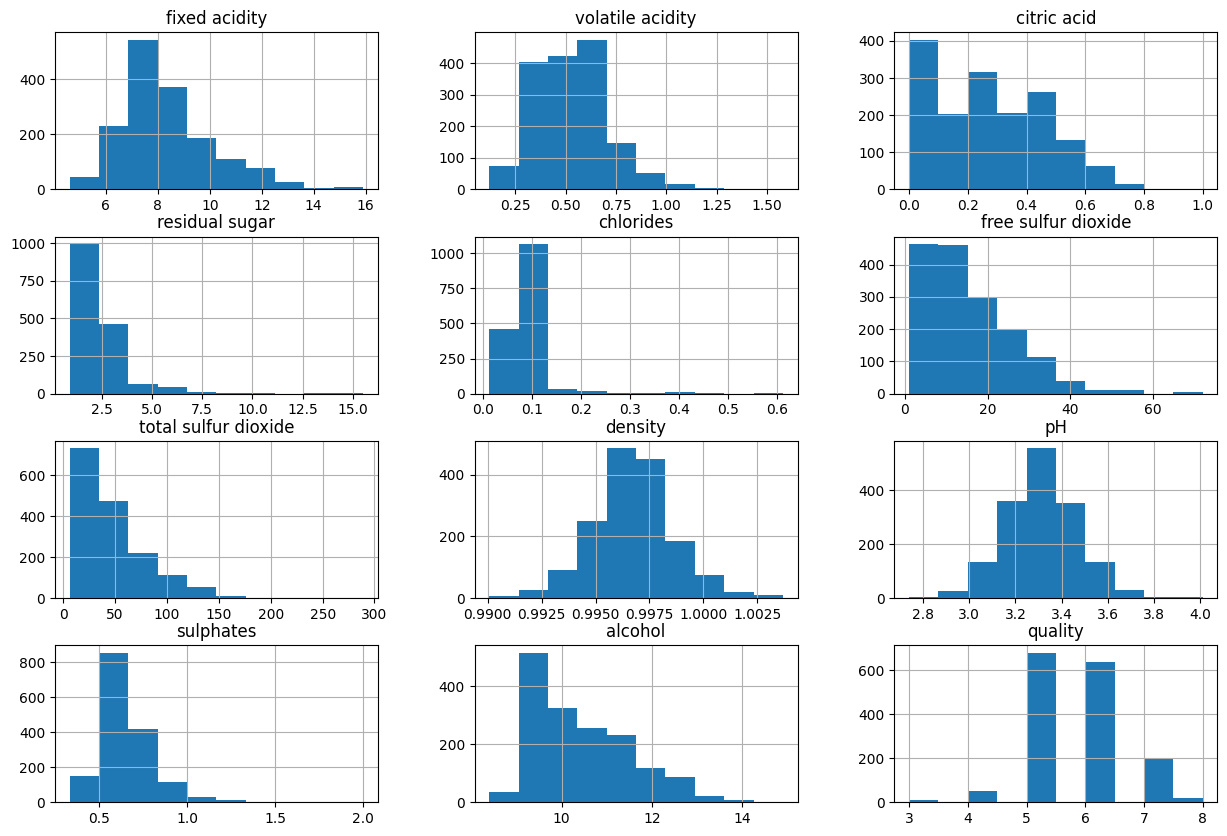

In [233]:
#Verificando a distribuição dos dados
tabela_vinhos.hist(figsize=(15,10))
plt.show()

###Analise da distribuição

Como é possivel verificar há alguns dados com uma assimetria forte a direita como Acidez Fixa, Ácido Cítrico, Açúcar Residual, Cloretos, Sulfatos, Dióxido de Enxofre Livre e Dióxido de Enxofre, mostrando que a maior parte dos vinhos tem esses valores mais baixos.

Outros dados como Acidez Volátil, pH e Densidade tem tem uma distribuição normal, ou seja, seus dados estão mais proximos da media.

Vale uma atenção para o Álcool, como uma distribuição um pouco mais ampla e a qualidade que diferente dos outros valores é um Inteiro, ou seja, é possivel verificar uma distribuição discreta, onde a grande parte dos vinhos esta com uma qualidade proximo a media e poucos vinhos tem uma qualidade baixa ou alta.


Proximo Passo, testar alguns modelos, vamos começar com a regressão linear e comparar com outros modelos melhores para esses tipos de distribuição.

In [234]:
#Regressão linear

# Separar o target
x = tabela_vinhos.drop('quality',axis=1)
y = tabela_vinhos['quality']

# Divisão Treino/Teste
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Criar e Treinar o Modelo Corretamente usando os dados de treino
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train) # Treina X_train para chegar em y_train

# Fazer a previsão nos dados de teste
lr_test_predictions = lin_reg.predict(x_test)

print("Previsões do Modelo (nos dados de teste):", lr_test_predictions[:10]) # Mostra as 10 primeiras previsões
print("Valores Reais (Gabarito dos dados de teste):", y_test.iloc[:10].values) # Mostra os 10 primeiros valores reais

Previsões do Modelo (nos dados de teste): [5.34666441 5.05631345 5.66446972 5.46451484 5.72518476 5.27928659
 5.03421667 5.12623347 5.74534288 5.68665032]
Valores Reais (Gabarito dos dados de teste): [6 5 6 5 6 5 5 5 5 6]


###Regressão Linear para uma amostra de dados (nos dados de teste)

Para a primeira análise, o modelo foi treinado com uma parte dos dados (dados de treino) e avaliado em uma parte separada e não vista (dados de teste).

Como é possível verificar, comparando as 10 primeiras previsões com os valores reais do conjunto de teste, é possível notar uma diferença. Isso nos dá uma indicação inicial de quão bem o modelo generaliza para dados novos, não apenas para os dados que ele viu durante o treinamento.

Próximo passo: Montar um gráfico de dispersão com a linha da regressão linear e suas predições (nos dados de teste) para verificar se ela está se aproximando dos valores.

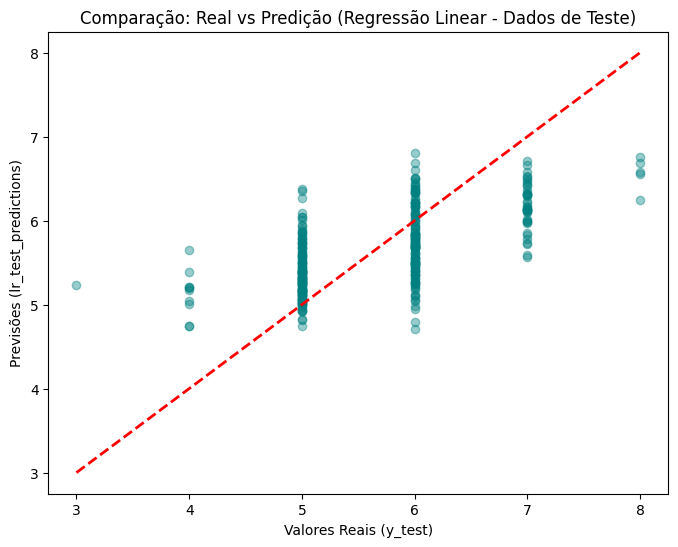

In [235]:
# Cria as predições para o conjunto de teste
lr_test_predictions = lin_reg.predict(x_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, lr_test_predictions, alpha=0.4, color='teal') # Usando y_test e as previsões no teste

# Linha de Referência (ideal onde Previsão == Real)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)

plt.xlabel('Valores Reais (y_test)')
plt.ylabel('Previsões (lr_test_predictions)')
plt.title('Comparação: Real vs Predição (Regressão Linear - Dados de Teste)')
plt.show()

### Análise do gráfico de qualidade vs valores da predição (Regressão Linear - Dados de Teste)

Este gráfico agora compara os valores reais do conjunto de teste com as previsões do modelo de Regressão Linear. É possível verificar que os pontos (previsões) se afastam da linha vermelha (que representa a previsão perfeita), especialmente nos valores mais extremos de qualidade. Isso sugere que o modelo ainda tem dificuldade em prever com precisão vinhos de muito baixa ou muito alta qualidade.

Próximo passo: Analisar as métricas do modelo para verificar o quão eficiente ele foi nos dados de teste.

In [238]:
# Calcular o MSE (Erro Médio Quadrático)
# Comparamos o Real (y_test) com a Previsão (lr_test_predictions) nos dados de teste
lin_mse = mean_squared_error(y_test, lr_test_predictions)

# Calcular o RMSE (Raiz do Erro Médio Quadrático)
lin_rmse = np.sqrt(lin_mse)

# Calcular o Erro Médio Absoluto
lin_mae = mean_absolute_error(y_test, lr_test_predictions)

# Calcular o R²
lin_r2 = r2_score(y_test, lr_test_predictions)

print(f"MSE (Teste): {lin_mse:.4f}")
print(f"RMSE (Teste): {lin_rmse:.4f}")
print(f"MAE (Teste): {lin_mae:.4f}")
print(f"R2 (Teste): {lin_r2:.4f}")

MSE (Teste): 0.3900
RMSE (Teste): 0.6245
MAE (Teste): 0.5035
R2 (Teste): 0.4032


### Análise de eficiência e acerto do modelo (Regressão Linear - Dados de Teste)

As métricas agora são calculadas no conjunto de teste, fornecendo uma avaliação mais realista do desempenho do modelo em dados não vistos. Os valores ainda parecem estar muito altos para o RMSE e MAE, totalizando uma diferença média de quase 0.5 ponto na qualidade.

O R² está muito baixo (cerca de 0.36), o que significa que o modelo de Regressão Linear explica apenas cerca de 36% da variância na qualidade do vinho. Isso confirma que este modelo não está capturando bem a relação entre as características do vinho e sua qualidade, e que devemos tentar outros modelos mais robustos.

Próximo passo: Tentar um modelo diferente que se encaixe melhor com a natureza dos nossos dados: DecisionTreeRegressor.

In [241]:
#Regressao linear multipla - DecisionTreeRegressor

# Preparação dos dados (Sempre o primeiro passo)
x = tabela_vinhos.drop('quality', axis=1)
y = tabela_vinhos['quality']

# Divisão Treino/Teste (Antes de qualquer treinamento)
# O random_state garante que os resultados sejam replicáveis
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Definição e Treinamento do Modelo
# Testar diferentes profundidades (max_depth) pode ajudar o R² a subir
tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_reg.fit(x_train, y_train);

# Predição nos dados de teste
tree_predictions = tree_reg.predict(x_test)

# Cálculo das Métricas
rgr_mse = mean_squared_error(y_test, tree_predictions)
rgr_rmse = np.sqrt(rgr_mse)
rgr_mae = mean_absolute_error(y_test, tree_predictions)
rgr_r2 = r2_score(y_test, tree_predictions)


print(f"MSE: {rgr_mse:.4f}")
print(f"RMSE: {rgr_rmse:.4f}")
print(f"MAE: {rgr_mae:.4f}")
print(f"R2: {rgr_r2:.4f}")

MSE: 0.4335
RMSE: 0.6584
MAE: 0.4964
R2: 0.3366


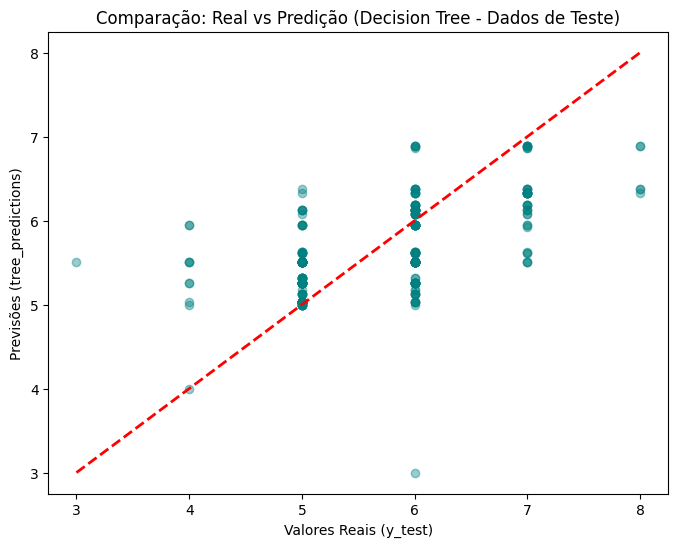

In [242]:
# Cria as predições para o conjunto de teste
tree_predictions = tree_reg.predict(x_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, tree_predictions, alpha=0.4, color='teal') # Usando y_test e as previsões no teste

#  Linha de Referência (ideal onde Previsão == Real)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)

plt.xlabel('Valores Reais (y_test)')
plt.ylabel('Previsões (tree_predictions)')
plt.title('Comparação: Real vs Predição (Decision Tree - Dados de Teste)')
plt.show()

### Análise de eficiência e acerto do modelo de árvore (Decision Tree - Dados de Teste)

Os valores ainda parecem estar muito altos para o RMSE e MAE, totalizando uma diferença de quase 0.4 pontos na qualidade.

O R² ainda esta muito baixo, ou seja, explica somente 33% das variações das notas, com isso vale a pena tentarmos outros modelos.

O gráfico traz algo bem parecido com o que já tínhamos na nossa regressão linear, aqui fica ligeiramente distante dos pontos com maior qualidade.

Próximo passo: Tentar um modelo diferente que se encaixe melhor com a quantidade de variáveis que temos. Vamos tentar usar o Random Forest!

In [243]:

# 1. Criar o modelo
# n_estimators=100 significa que ele vai criar 100 árvores diferentes
# n_jobs=-1 usa todos os núcleos do seu processador para ser mais rápido
forest_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Treinar o modelo
forest_reg.fit(x_train, y_train)

# 3. Fazer as previsões
forest_previsoes = forest_reg.predict(x_test)

# Cálculo das Métricas
forest_mse = mean_squared_error(y_test, forest_previsoes)
forest_rmse = np.sqrt(forest_mse)
forest_mae = mean_absolute_error(y_test, forest_previsoes)
forest_r2 = r2_score(y_test, forest_previsoes)


print(f"MSE: {forest_mse:.4f}")
print(f"RMSE: {forest_rmse:.4f}")
print(f"MAE: {forest_mae:.4f}")
print(f"R2: {forest_r2:.4f}")

MSE: 0.3012
RMSE: 0.5489
MAE: 0.4224
R2: 0.5390


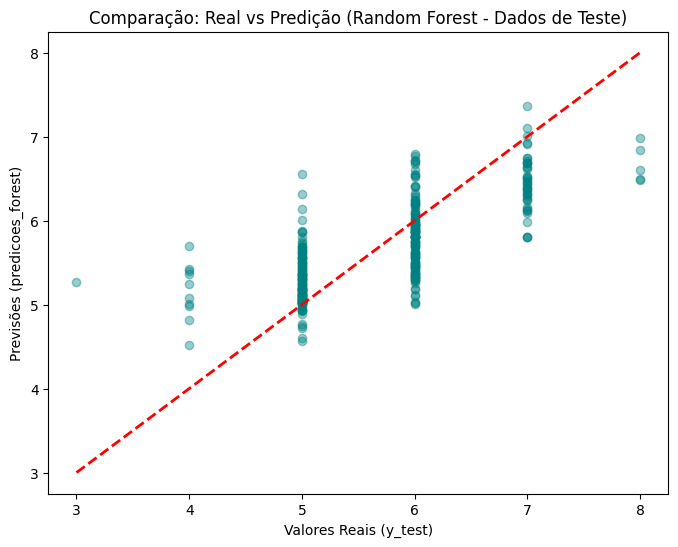

In [244]:
# Cria as predições para a tabela TODA que você usou no X
predicoes_forest = forest_reg.predict(x_test)


plt.figure(figsize=(8, 6))
plt.scatter(y_test, predicoes_forest, alpha=0.4, color='teal')

#  Linha de Referência
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)

plt.xlabel('Valores Reais (y_test)')
plt.ylabel('Previsões (predicoes_forest)')
plt.title('Comparação: Real vs Predição (Random Forest - Dados de Teste)')
plt.show()

### Análise de eficiência e acerto do modelo de Random Forest (Dados de Teste)

Os valores caíram bastante, em comparação com os outros dois modelos, houve uma queda de mais de 0.1 nos erros (RMSE e MAE).

O R² já está em algo aceitável para a complexidade que é avaliar vinhos, batendo o valor de 0.5. Isso indica que o modelo Random Forest consegue explicar cerca de 50% da variância na qualidade do vinho nos dados de teste.

O gráfico aqui mostra que os pontos das previsões estão mais próximos da linha de referência (onde a previsão é igual ao valor real), tanto na média quanto nos extremos, o que parece bem aceitável e um bom indicativo de que o modelo está generalizando melhor.

Próximo passo: Verificar quais características mais afetam a nota do vinho, utilizando o melhor modelo que encontramos.

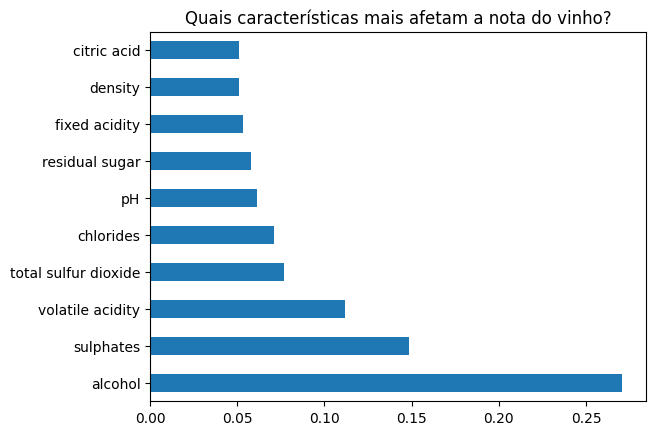

In [210]:
# Importância das colunas
importancias = pd.Series(forest_reg.feature_importances_, index=x.columns)
importancias.nlargest(10).plot(kind='barh')

plt.title('Quais características mais afetam a nota do vinho?')
plt.show()

###Analise de Importancia dos parametros para determinar a qualidade do vinho

Alcohol (Álcool): Com uma importância de aproximadamente 0.2709 é o fator mais significativo na previsão da qualidade do vinho. Vinhos com maior teor alcoólico tendem a ser associados a uma melhor qualidade.

Sulphates (Sulfatos): Com uma importância de aproximadamente 0.1484, os sulfatos são o segundo fator mais influente. Os sulfatos são aditivos de vinho que podem contribuir para o sabor e a estabilidade.

Volatile acidity (Acidez Volátil): Com importância de aproximadamente 0.1115, a acidez volátil é terceiro indicador mais importante. Níveis mais altos de acidez volátil geralmente estão associados a vinhos de menor qualidade, pois indicam a presença de bactérias e defeitos

Em resumo, o álcool, sulfatos e acidez volátil são os atributos que o modelo Random Forest considerou mais relevantes para prever a qualidade do vinho. Isso sugere que mudanças nessas características teriam o maior impacto na nota de qualidade do vinho, de acordo com o modelo.

### Comparativo dos Modelos de Regressão

Após testarmos três diferentes modelos de regressão, observamos os seguintes resultados nas métricas de desempenho:

| Modelo                 | MSE    | RMSE   | MAE    | R²     |
| :--------------------- | :----- | :----- | :----- | :----- |
| Regressão Linear       | 0.3900 | 0.6245 | 0.5035 | 0.4032 |
| Decision Tree Regressor| 0.4335 | 0.6584 | 0.4964 | 0.3366 |
| Random Forest Regressor| 0.3012 | 0.5489 | 0.4224 | 0.5390 |

**Análise:**

*   **Regressão Linear:** Apresentou um R² de aproximadamente 0.40, indicando que explicava cerca de 40% da variância na qualidade. O MAE de 0.50 sugeria um erro médio de meio ponto na escala de qualidade.
*   **Decision Tree Regressor:** Surpreendentemente, este modelo teve um desempenho ligeiramente pior que a Regressão Linear, com um R² de 0.33 e um MAE similar. Isso pode indicar que uma única árvore de decisão com profundidade limitada não foi suficiente para capturar a complexidade dos dados.
*   **Random Forest Regressor:** Demonstrou o melhor desempenho entre os três. Com um R² de 0.54, ele conseguiu explicar mais da metade da variância na qualidade do vinho, um avanço significativo. Seu MAE de 0.42 indica que, em média, as previsões estavam cerca de 0.42 pontos distantes dos valores reais, uma melhoria notável em relação aos outros modelos.

**Conclusão:** O **Random Forest Regressor** foi o modelo escolhido por apresentar as melhores métricas de desempenho, especialmente um R² superior e o menor MAE e RMSE, indicando uma maior precisão e capacidade de generalização para prever a qualidade do vinho com base nas características fornecidas.

### Metricas e suas explicações

<b> Mean Squared Error - Erro Quadrático Médio </b> ->  É a média das diferenças ao quadrado entre os valores reais de y (qualidade real do vinho) e as predictions_completo (qualidades de vinho previstas). Eleva-se ao quadrado os erros, o que significa que erros maiores têm um impacto desproporcionalmente maior no MSE.


<b> Root Mean Squared Error - Raiz do Erro Quadrático Médio </b> ->  É a raiz quadrada do MSE. É frequentemente preferido em relação ao MSE porque possui as mesmas unidades da variável alvo (quality), tornando-o mais fácil de interpretar. Um RMSE menor é melhor.

<b> Mean Absolute Error - Erro Médio Absoluto </b> -> É a média das diferenças absolutas entre os valores reais de y e as predictions_completo. Ao contrário do MSE, ele não penaliza os erros maiores tão severamente. Ele fornece uma medida direta da magnitude média dos erros. Um MAE menor é melhor.

<b> R-quadrado </b> -> Esta métrica representa a proporção da variância na variável dependente (qualidade do vinho) que é explicável pelas variáveis independentes. Um R2 de 1 significa que o modelo prevê perfeitamente a variável alvo e um R2 mais alto indica um ajuste melhor do modelo.